# Tarea 3
## II.2. Implementación

Modelo de Ising en dos dimensiones en red cuadrada, con hamiltoniano

$$H = -J \sum_{\langle i,j \rangle} s_i s_j,\qquad s_i=\pm1,$$

interacción a primeros vecinos y condiciones periódicas de frontera.

**Convenciones.**
- $k_B=1$, así que $T$ se mide en unidades de $J/k_B$.
- Un paso Monte Carlo (MCS) $=N=L^2$ intentos de volteo, para que cada espín reciba en promedio una oportunidad por paso.
- Las observables se reportan normalizados por espín: $e=E/N$, $m=M/N$.
- Se descartan los primeros pasos (termalización) antes de promediar.


### Temperatura crítica

De la dualidad de Kramers-Wannier, suponiendo una única transición, ésta ocurre en el punto fijo $L_c=L_c^*$, donde $\sinh 2L\sinh 2L^*=1$ da

$$\sinh\left(\frac{2J}{k_BT_c}\right)=1 \quad\Longrightarrow\quad T_c=\frac{2J}{k_B\ln(1+\sqrt2)}\simeq2.269185\,\frac{J}{k_B}.$$


In [1]:
import numpy as np
import random

k = 1   # constante de Boltzmann, k_B = 1 en unidades reducidas

## Implementación

In [2]:
#Paso 1: Generar una configuración inicial aleatoria de espines en una red cuadrada de tamaño LxL. Cada espín puede tomar valores +1 o -1.

#DEFINICIÓN DE FUNCIONES

def energy(lattice, J):
    """Energia total de una configuracion con condiciones periodicas.
   
    Parameters
    ----------
    lattice : array
        Configuracion (L, L) de espines +-1.
    J : float
        Constante de acoplamiento.

    Returns
    -------
    float
        Energia total E.
    """
   
    L = len(lattice)
    H = 0
    for i in range(L):
        for j in range(L):
            #vecinos horizontales
            H += lattice[i][j] * ( lattice[i][(j+1) % L] + lattice[i][(j-1) % L]) # el modulo L se hace para tener en cuenta 
            # vecinos verticales                                                    las condiciones periodicas de frontera
            H += lattice[i][j] * ( lattice[(i+1) % L][j] + lattice[(i-1) % L][j])
    return (-J/2) * H  #Divido entre dos porque cada par de espines se cuenta dos veces

def create_lattice(L):
    """Genera una configuracion inicial de espines en una red L x L.

    Parameters
    ----------
    L : int
        Lado de la red. El numero total de espines es N = L*L.
        
    Returns
    -------
    array
        Arreglo (L, L) de enteros con valores +-1.
    """
    lattice = np.zeros((L, L))
    for i in range(L):
        for j in range(L):
            lattice[i][j] = np.random.choice([-1, 1])      
    return lattice


def temperatura_critica(J):
    """Tc = 2J/(k ln(1+sqrt(2)))
       
        Parameters
        ----------
        J : float
            Constante de acoplamiento.
    
        Returns
        -------
        float
            Temperatura critica.
    """
    return 2*J/(k*np.log(1+np.sqrt(2)))

## Metropolis

In [3]:
def metropolis(L, J, T, t):
    """Ejecuta el algoritmo de Metropolis.
    
        Parameters
        ----------
        L : int
            Lado de la red. El numero total de espines es N = L*L.
        J : float
            Constante de acoplamiento.
        T : float
            Temperatura.    
        t : int
            Numero de pasos Monte Carlo (MCS) a ejecutar.
        
        Returns
        -------
        energy_list : list
            Lista de energia por espin e=E/N en cada paso.
        magnetization_list : list
            Lista de magnetizacion por espin m=M/N en cada paso.
        """
    
    beta = 1/(T*k)
    lattice = create_lattice(L)
    N = L*L

    E = energy(lattice, J)
    M = np.sum(lattice) # La magnetizacion total es la suma de todos los espines, M = sum(s_i)

    energy_list = []
    magnetization_list = []

    for paso in range(t):

        for _ in range(N):   # un paso Monte Carlo = N intentos, para que en promedio cada espin tenga una oportunidad

            #Paso 2: Se selecciona un espín de la red al azar.
            random_spin = np.random.randint(0, L*L)
            i = int(random_spin/L)
            j = random_spin%L
            s = lattice[i][j]

            #Paso 3: Se calcula el cambio de energía si se voltea este espín.
            # (solo cambian los terminos del hamiltoniano que tocan a (i,j), por eso basta mirar sus 4 vecinos)
            vecinos = (lattice[(i+1)%L][j] + lattice[(i-1)%L][j] +
                       lattice[i][(j+1)%L] + lattice[i][(j-1)%L])
            delta_energy = 2*J*s*vecinos

            #Paso 4: Si ∆E ≤0 se acepta el cambio
            if delta_energy <= 0:
                lattice[i][j] = -s
                E += delta_energy   
                M -= 2*s            # el espin cambia de s a -s, asi que M_final = M_inicial - s - s = M_inicial - 2*s

            #Paso 5: Si ∆E > 0, se acepta el cambio con prob. exp(−β∆E)
            else:
                p = random.random()
                if p < np.exp(-beta*delta_energy):
                    lattice[i][j] = -s
                    E += delta_energy
                    M -= 2*s

        #Paso 6: se guarda el estado del sistema despues de este paso Monte Carlo
        energy_list.append(E/N)
        magnetization_list.append(M/N)

    return energy_list, magnetization_list

In [4]:
# empaco termalizacion + promedios en una sola funcion para no repetir codigo

def simulate(L, J, T, t, t_term):
    """ Simula el sistema y calcula los promedios de energia y magnetizacion.
         
          Parameters
          ----------
          L : int
                Lado de la red. El numero total de espines es N = L*L.
          J : float
                Constante de acoplamiento.
          T : float
                Temperatura.    
          t : int
                Numero de pasos Monte Carlo (MCS) a ejecutar.
          t_term : int
                Numero de pasos Monte Carlo (MCS) a descartar como termalizacion.
          
          Returns
          -------
          e_mean : float
                Promedio de energia por espin <e>.
          m_mean : float
                Promedio de magnetizacion por espin <m>.
     """
     
    energia, magnetizacion = metropolis(L, J, T, t)
    e = energia[t_term:]
    m = magnetizacion[t_term:]

    e_mean = np.mean(e)
    m_mean = np.mean(np.abs(m))
    
    return e_mean, m_mean

## Validación: límites conocidos

- $T\to0$: estado fundamental, $e\to-2J$ y $|m|\to1$.
- $T\to\infty$: configuraciones aleatorias, $e\to0$ y $m\to0$.

In [5]:
Tc = temperatura_critica(1)
print("Tc =", Tc, "\n")


for T in [0.5, 1.0, Tc, 4.0, 10.0]:
    e_mean, m_mean = simulate(L=16, J=1, T=T, t=7500, t_term=1500)
    print(f"T = {T:6.3f}   e = {e_mean:+.4f}   |m| = {m_mean:.4f}")

Tc = 2.269185314213022 

T =  0.500   e = -2.0000   |m| = 1.0000
T =  1.000   e = -1.9976   |m| = 0.9994
T =  2.269   e = -1.4480   |m| = 0.7080
T =  4.000   e = -0.5558   |m| = 0.1048
T = 10.000   e = -0.2039   |m| = 0.0622


## Series temporales a $T<T_c$, $T=T_c$ y $T>T_c$

Se grafican las series completas, incluyendo la termalización, para poder verificar
visualmente que el sistema alcanza el equilibrio antes de empezar a medir.


In [6]:
J = 1
L = 16
t = 7500        # pasos Monte Carlo (incluye termalizacion)
t_term = 1500   # se descartan estos primeros pasos al promediar

Tc = temperatura_critica(J)

e_low, m_low = metropolis(L, J, Tc-1, t)
e_tc,  m_tc  = metropolis(L, J, Tc, t)
e_high, m_high = metropolis(L, J, Tc+1, t)

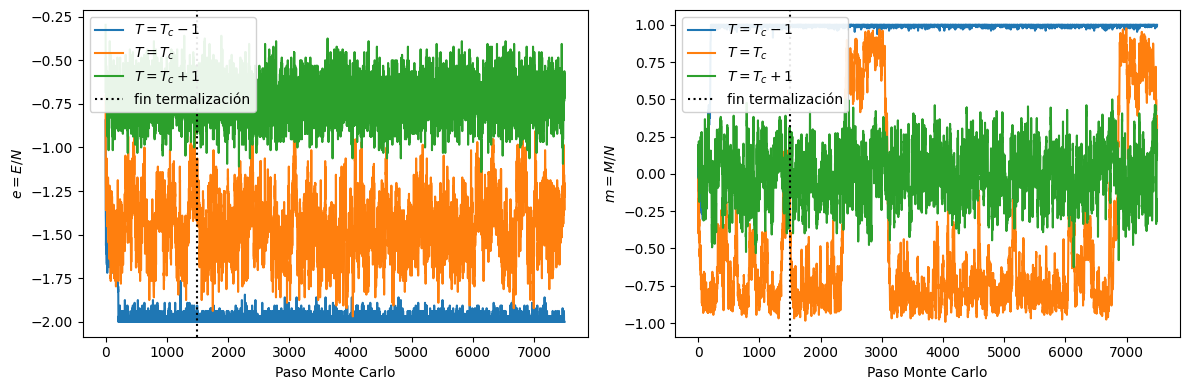

Energía promedio del sistemaa a temperutra critica     : e_c    =  -1.4642083333333333
Energía promedio del sistema a temperatura menor que Tc: e_low  =  -1.9830208333333332
Energía promedio del sistema a temperatura mayor que Tc: e_high =  -0.7202864583333334

Magnetización promedio del sistemaa a temperutra critica     : m_c    =  0.7274622395833333
Magnetización promedio del sistema a temperatura menor que Tc: m_low  =  0.9955416666666667
Magnetización promedio del sistema a temperatura mayor que Tc: m_high =  0.13897916666666665


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(e_low, label=r'$T=T_c-1$')
ax[0].plot(e_tc, label=r'$T=T_c$')
ax[0].plot(e_high, label=r'$T=T_c+1$')
ax[0].axvline(t_term, color='k', linestyle=':', label='fin termalización')
ax[0].set_xlabel('Paso Monte Carlo')
ax[0].set_ylabel(r'$e = E/N$')
ax[0].legend(loc='upper left', framealpha=0.9)

ax[1].plot(m_low, label=r'$T=T_c-1$')
ax[1].plot(m_tc, label=r'$T=T_c$')
ax[1].plot(m_high, label=r'$T=T_c+1$')
ax[1].axvline(t_term, color='k', linestyle=':', label='fin termalización')
ax[1].set_xlabel('Paso Monte Carlo')
ax[1].set_ylabel(r'$m = M/N$')
ax[1].legend(loc='upper left', framealpha=0.9)

fig.tight_layout()
plt.show()

# se descartan los primeros t_term pasos (termalizacion) antes de promediar
mean_e_low  = np.mean(e_low[t_term:])
mean_e_tc   = np.mean(e_tc[t_term:])
mean_e_high = np.mean(e_high[t_term:])

print("Energía promedio del sistemaa a temperutra critica     : e_c    = ", mean_e_tc)
print("Energía promedio del sistema a temperatura menor que Tc: e_low  = ", mean_e_low)
print("Energía promedio del sistema a temperatura mayor que Tc: e_high = ", mean_e_high)
print()

# se toma valor absoluto: en una red finita el sistema puede voltearse por completo (simetria Z2),
# entonces <m> sin valor absoluto tiende a 0 incluso en la fase ordenada
mean_m_low  = np.mean(np.abs(m_low[t_term:]))
mean_m_tc   = np.mean(np.abs(m_tc[t_term:]))
mean_m_high = np.mean(np.abs(m_high[t_term:]))

print("Magnetización promedio del sistemaa a temperutra critica     : m_c    = ", mean_m_tc)
print("Magnetización promedio del sistema a temperatura menor que Tc: m_low  = ", mean_m_low)
print("Magnetización promedio del sistema a temperatura mayor que Tc: m_high = ", mean_m_high)

**Sobre el tiempo de termalización.** Lejos de $T_c$ el sistema es estacionario casi desde el paso 0, así que $t_{\rm term}=1500$ es más que suficiente. Cerca de $T_c$ la magnetización cambia de rama (de $m\approx+1$ a $m\approx-1$ y viceversa) varias veces a lo largo de todo el run, como se ve en la curva naranja.

Esto se explica mediante la simetría del hamiltoniano ($s_i\to-s_i$ deja $H$ invariante) que solo se rompe espontáneamente en el límite $N\to\infty$; en una red finita ambos signos de $m$ son igualmente válidos. A $T_c$ la longitud de correlación $\xi$ es comparable al tamaño de la red, así que el sistema puede nuclear un dominio del signo opuesto y que este crezca hasta invadir toda la red, volteando $m$ globalmente.

Justamente por estos volteos es que se **promedia $|m|$ y no $m$.** promediar $m$ sin valor absoluto da $\langle m\rangle\approx0$ incluso en la fase ordenada, porque los dos signos se cancelan en el promedio. $\langle|m|\rangle$ sí converge al valor físico de la magnetización espontánea.

Un $t_{\rm term}$ riguroso se obtendría comparando la convergencia desde una condición inicial aleatoria y una ordenada, o estimando el tiempo de autocorrelación de $e(t)$. En la práctica basta fijar $t_{\rm term}$ según el peor caso (cerca de $T_c$) y usarlo para todas las temperaturas.

## Barrido en temperatura

Se calcula la energía y magnetización promedio por espín para un barrido de temperaturas, incluyendo la temperatura crítica. Se reportan los valores promedio después de descartar los primeros pasos (termalización).

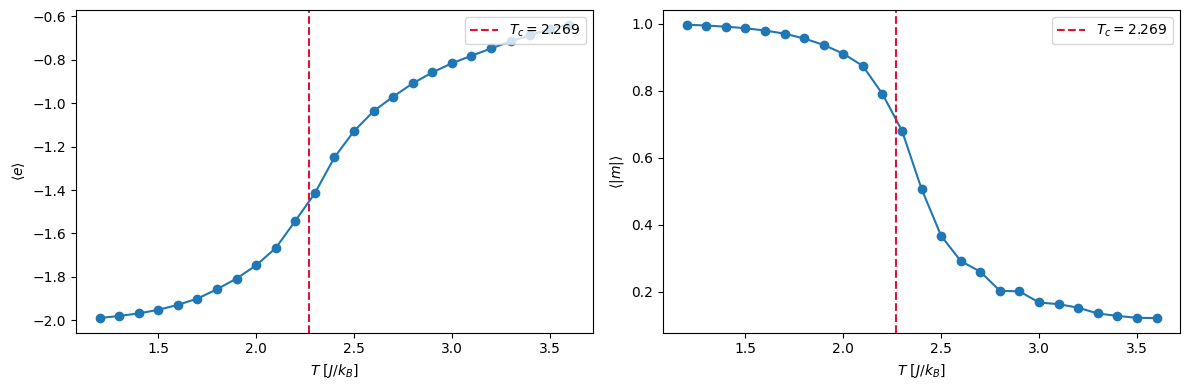

In [8]:
Ts = np.linspace(1.2, 3.6, 25)

e_vals, m_vals = [], []

for T in Ts:
    e_mean, m_mean = simulate(L=16, J=1, T=T, t=t, t_term=t_term)
    e_vals.append(e_mean)
    m_vals.append(m_mean)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(Ts, e_vals, 'o-')
ax[0].axvline(Tc, color='crimson', linestyle='--', label=r'$T_c=2.269$')
ax[0].set_xlabel(r'$T\ [J/k_B]$')
ax[0].set_ylabel(r'$\langle e\rangle$')
ax[0].legend(loc='upper right')

ax[1].plot(Ts, m_vals, 'o-')
ax[1].axvline(Tc, color='crimson', linestyle='--', label=r'$T_c=2.269$')
ax[1].set_xlabel(r'$T\ [J/k_B]$')
ax[1].set_ylabel(r'$\langle|m|\rangle$')
ax[1].legend(loc='upper right')

fig.tight_layout()
plt.show()

## Discusión

Los resultados aquí presentados de energía en función del tiempo y magnetización en función de la temperatura, reproducen el comportamiento esperado del modelo de Ising 2D.

**Energía.** En las series temporales, $e(t)$ se estabiliza casi de inmediato lejos de $T_c$, y de forma más lenta y ruidosa justo en $T_c$. En el barrido, $e(T)$ pasa de forma suave de $\simeq-2J$ (todos los espines alineados, estado fundamental) a valores cercanos a $0$ (espines efectivamente independientes a $T$ alta), sin ningún salto discontinuo. Esto es consistente con una transición de segundo orden, donde la energía interna es continua en $T_c$.

**Magnetización:** $\langle|m|\rangle$ cae de $\approx1$ a $\approx0$ en una ventana relativamente angosta alrededor de $T\approx2.3$, cerca pero no exactamente igual a $T_c=2.269$. La diferencia es un efecto de tamaño finito: en una red $L\times L$ finita no hay una discontinuidad genuina en $\langle|m|\rangle$ (eso solo ocurre en $N\to\infty$); una red más grande haría la caída más abrupta y más cercana a $T_c$.

**Consistencia entre las dos gráficas:** El cambio más rápido de $e(T)$ ocurre en la misma región donde cae $\langle|m|\rangle$, como debe ser: ambas son manifestaciones de la misma transición. Formalmente $c=\partial e/\partial T$, así que, aunque aquí no se calculó el calor específico explícitamente, su máximo (que marca la transición) coincide con la zona de mayor pendiente de $e(T)$, justo donde cae $\langle|m|\rangle$.